<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-OcampoGiraldo/Evaluacion2/OcampoGiraldo/Evaluaci%C3%B3n_2_prog_cientifica_prueba_de_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CONFIGURACIÓN DE GRÁFICAS

In [1]:
# REVISAR: celda original usa !sudo apt-get (Colab); deshabilitada para ejecución local, LaTeX ya está instalado en esta máquina
# !sudo apt-get update
# !sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


# OBTENCIÓN DE DATOS

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Carga de datos
datos = np.load('../SolucionReferencia_0000/datos_0000.npz') # Asegúrate de que este archivo esté en tu carpeta
X = jnp.array(datos['X'])
y = jnp.array(datos['y'])
t = jnp.array(datos['t'])

K = 25 # Número de frecuencias (valor de la referencia, para comparación)

# ENTRENAMIENTO DE LA RED USANDO LAS DOS BASES

In [3]:
# Neural network model
def model(W1, W2, x):
    # x es el vector de entrada con forma (256,) que representa una señal individual
    # W1 es la matriz de pesos de la capa oculta, con forma (2K, 256)
    # W2 es la matriz de pesos de la capa de salida, con forma (256, 2K)

    hidden = jnp.tanh(jnp.dot(W1, x))


    output = jnp.dot(W2, hidden)


    return output

# función de pérdida (Error medio cuádractico)
def loss_fn(W1, W2, X_batch):
    # X_batch es un lote (batch) de señales, con forma (batch_size, 256)

    # jax.vmap vectoriza la función 'model' para procesar todo el batch de golpe sin usar un ciclo for.
    # in_axes=(None, None, 0) indica que W1 y W2 no se iteran (son los mismos para todos), pero X_batch se itera a lo largo del eje 0.
    predictions = jax.vmap(model, in_axes=(None, None, 0))(W1, W2, X_batch)

    # Calcula y retorna el Error Cuadrático Medio (MSE) entre las predicciones de la red y el lote original
    return jnp.mean(jnp.square(predictions - X_batch))

# Función de actualización para el gradiente descendente
@jax.jit  # Compila la función usando XLA para que la ejecución del entrenamiento sea muchísimo más rápida
def update(W1, W2, X_batch, lr):
    # jax.value_and_grad evalúa la función de pérdida y a la vez calcula sus gradientes.
    # argnums=(0, 1) indica que queremos derivar con respecto a W1 y W2 (los argumentos en posición 0 y 1).
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0, 1))(W1, W2, X_batch)

    # Se desempaquetan los gradientes calculados para cada matriz de pesos
    W1_grad, W2_grad = grads

    # Se actualiza W1 restando su gradiente multiplicado por la tasa de aprendizaje (lr) (Descenso de gradiente)
    W1 -= lr * W1_grad

    # Se actualiza W2 restando su gradiente multiplicado por la tasa de aprendizaje (lr)
    W2 -= lr * W2_grad

    # Retorna los nuevos pesos ajustados y el valor actual de la pérdida
    return W1, W2, loss

# Función de inicialización de parametros (Random)
def init_random_params(key):
    # JAX requiere control explícito de la aleatoriedad. Aquí dividimos la clave maestra en 3 subclaves distintas.
    key, subkey1, subkey2 = jax.random.split(key, 3)

    # Inicializa los pesos de W1 usando una distribución normal (gaussiana) generada con subkey1, escalando el resultado por 0.01
    # Convierte entradas de tamaño 256 a un espacio de tamaño 2K
    W1 = jax.random.normal(subkey1, (2 * K, 256)) * 0.01

    # Inicializa los pesos de W2 de la misma forma, usando subkey2, proyectando de vuelta desde 2K a 256
    W2 = jax.random.normal(subkey2, (256, 2 * K)) * 0.01

    # Retorna ambas matrices de pesos inicializadas
    return W1, W2

# Función de inicialización de parametros (Parameter initialization function) (Fourier)
def init_fourier_params(key, t_vals):
    # Divide la clave en 2 subclaves: una maestra de reserva y una para generar números aleatorios luego.
    key, subkey = jax.random.split(key)

    # Lista para ir guardando las ondas (senos y cosenos) que formarán la base de Fourier
    fourier_rows = []

    # Itera sobre las frecuencias deseadas, desde 1 hasta el valor K (armónicos)
    for k_val in range(1, K + 1):
        # Calcula y agrega una fila que representa una onda seno para la frecuencia actual k_val en el tiempo t_vals
        fourier_rows.append(jnp.sin(2 * jnp.pi * k_val * t_vals))

        # Calcula y agrega una fila que representa una onda coseno para la frecuencia actual k_val en el tiempo t_vals
        fourier_rows.append(jnp.cos(2 * jnp.pi * k_val * t_vals))

    # Convierte la lista de filas (arreglos) en una sola matriz de pesos bidimensional usando JAX
    W1_fourier = jnp.array(fourier_rows)

    # W2 se inicializa de manera aleatoria normal (igual que en la función anterior) usando la subclave generada
    W2_random = jax.random.normal(subkey, (256, 2 * K)) * 0.01

    # Retorna la matriz de pesos fijada por Fourier (W1) y la matriz aleatoria (W2)
    return W1_fourier, W2_random

def train_network(W1, W2, X_train, iterations=3000, lr=0.05):
    # Lista vacía que almacenará el valor de la pérdida en cada iteración para poder graficarla después
    losses = []

    # Bucle que se repetirá la cantidad de veces definida por el parámetro 'iterations' (por defecto 2000)
    for i in range(iterations):
        # Llama a la función 'update' para ajustar los pesos en base a todo el conjunto de datos de entrenamiento (X_train)
        W1, W2, loss = update(W1, W2, X_train, lr)

        # Guarda el valor de la pérdida calculada en este paso dentro de la lista
        losses.append(loss)

    # Retorna los pesos óptimos al final del entrenamiento y el historial completo de pérdidas
    return W1, W2, losses

# Crea la llave principal del generador de números pseudoaleatorios de JAX con la semilla '784' (para reproducibilidad)
key = jax.random.PRNGKey(784)

# --- Entrenamiento Aleatorio ---
# Obtiene los pesos inicializados aleatoriamente llamando a init_random_params
W1_rand, W2_rand = init_random_params(key)

# Llama a la función de entrenamiento usando los pesos aleatorios, sobre el dataset X, con un learning rate de 0.02
W1_rand_opt, W2_rand_opt, losses_rand = train_network(W1_rand, W2_rand, X, lr=0.05)

# --- Entrenamiento Fourier ---
# Obtiene W1 inicializada como serie de Fourier y W2 aleatoria (se necesita pasar 't', un vector de tiempo externo)
W1_four, W2_four = init_fourier_params(key, t)

# Llama a la función de entrenamiento usando los pesos híbridos (Fourier), sobre el dataset X, con un learning rate de 0.02
W1_four_opt, W2_four_opt, losses_four = train_network(W1_four, W2_four, X, lr=0.05)



# RECONSTRUCCIÓN: ENERGÍA MEDIA DEL DATASET

In [4]:
# 1. Tomamos una señal de ejemplo, para hacer la comparación de Fourier
x_sample = X[0]

# 2. Proyección lineal de tu capa inicializada con Fourier
fourier_projection = jnp.dot(W1_four, x_sample)

# 3. Calculamos la FFT real usando numpy
fft_result = np.fft.rfft(x_sample)

# 4. Seleccionamos la frecuencia k = 1
k_val = 1
k_index = k_val - 1 # Índice base para k=1 en la matriz W1

# Calculamos la magnitud obtenida por la capa W1
# El seno está en el índice par (0) y el coseno en el impar (1) para k=1
sin_val = fourier_projection[2 * k_index]
cos_val = fourier_projection[2 * k_index + 1]
mag_w1 = jnp.sqrt(sin_val**2 + cos_val**2)

# Calculamos la magnitud obtenida por np.fft (índice 1 corresponde a k=1)
mag_fft = np.abs(fft_result[k_val])

# Calculamos la diferencia absoluta
diff = np.abs(mag_w1 - mag_fft)

#Cálculo energía media del dataset
datos = np.load('../SolucionReferencia_0000/datos_0000.npz')
X = jnp.array(datos['X'])

energia_media = (X**2).mean()

print(f"Energía media del dataset: {energia_media:.3f}")
print(f"Magnitud calculada por capa de la base de Fourier:  {mag_w1:f}")
print(f"Magnitud calculada por np.fft:   {mag_fft:f}")
print(f"Diferencia absoluta:             {diff:.2e}")

Energía media del dataset: 0.678
Magnitud calculada por capa de la base de Fourier:  1.756592
Magnitud calculada por np.fft:   1.756592
Diferencia absoluta:             3.58e-07


# ERROR RELATIVO PARA CADA CASO

In [5]:
# Definimos una lista con los tres regímenes existentes en los datos (0, 1 y 2)
regimenes = [0, 1, 2]

# Iniciamos un bucle for para iterar y calcular los errores por cada régimen de manera independiente
for reg in regimenes:

    # Filtramos el conjunto de datos 'X' para quedarnos solo con las señales correspondientes al régimen actual evaluado usando la etiqueta 'y'
    X_reg = X[y == reg]

    # Utilizamos jax.vmap para vectorizar la función 'model' y generar las reconstrucciones de todas las señales del régimen con la red aleatoria
    pred_rand = jax.vmap(model, in_axes=(None, None, 0))(W1_rand_opt, W2_rand_opt, X_reg)

    # Utilizamos jax.vmap de la misma forma para generar las reconstrucciones de todas las señales del régimen con la red de Fourier
    pred_four = jax.vmap(model, in_axes=(None, None, 0))(W1_four_opt, W2_four_opt, X_reg)

    # Calculamos la norma L2 (error) de cada señal aleatoria usando axis=1, y luego extraemos el promedio (mean) de todo el bloque
    norma_error_rand = jnp.linalg.norm(X_reg - pred_rand, axis=1).mean()

    # Calculamos la norma L2 (error) de cada señal de Fourier usando axis=1, y luego extraemos el promedio (mean) de todo el bloque
    norma_error_four = jnp.linalg.norm(X_reg - pred_four, axis=1).mean()

    # Calculamos la norma L2 promedio de las señales originales de este régimen, la cual será nuestro denominador de normalización
    norma_original = jnp.linalg.norm(X_reg, axis=1).mean()

    # Calculamos el error relativo medio de la red aleatoria dividiendo su error promedio entre la magnitud original promedio
    error_rel_rand = norma_error_rand / norma_original

    # Calculamos el error relativo medio de la red de Fourier dividiendo su error promedio entre la magnitud original promedio
    error_rel_four = norma_error_four / norma_original

    # Imprimimos un separador visual y el nombre del régimen que estamos evaluando actualmente
    print(f"\n--- Resultados para el Régimen {reg} ---")

    # Imprimimos el resultado del error relativo medio para la inicialización aleatoria limitando a 4 decimales
    print(f"Error relativo medio (Aleatoria): {error_rel_rand:.4f}")

    # Imprimimos el resultado del error relativo medio para la inicialización de Fourier limitando a 4 decimales
    print(f"Error relativo medio (Fourier): {error_rel_four:.4f}")


--- Resultados para el Régimen 0 ---
Error relativo medio (Aleatoria): 0.3407
Error relativo medio (Fourier): 0.3003

--- Resultados para el Régimen 1 ---
Error relativo medio (Aleatoria): 0.4028
Error relativo medio (Fourier): 0.3691

--- Resultados para el Régimen 2 ---
Error relativo medio (Aleatoria): 0.3366
Error relativo medio (Fourier): 0.3711


# RECONSTRUCCIÓN DE LA SEÑALES Y COMPARACIÓN CON LA SEÑAL ORIGINAL

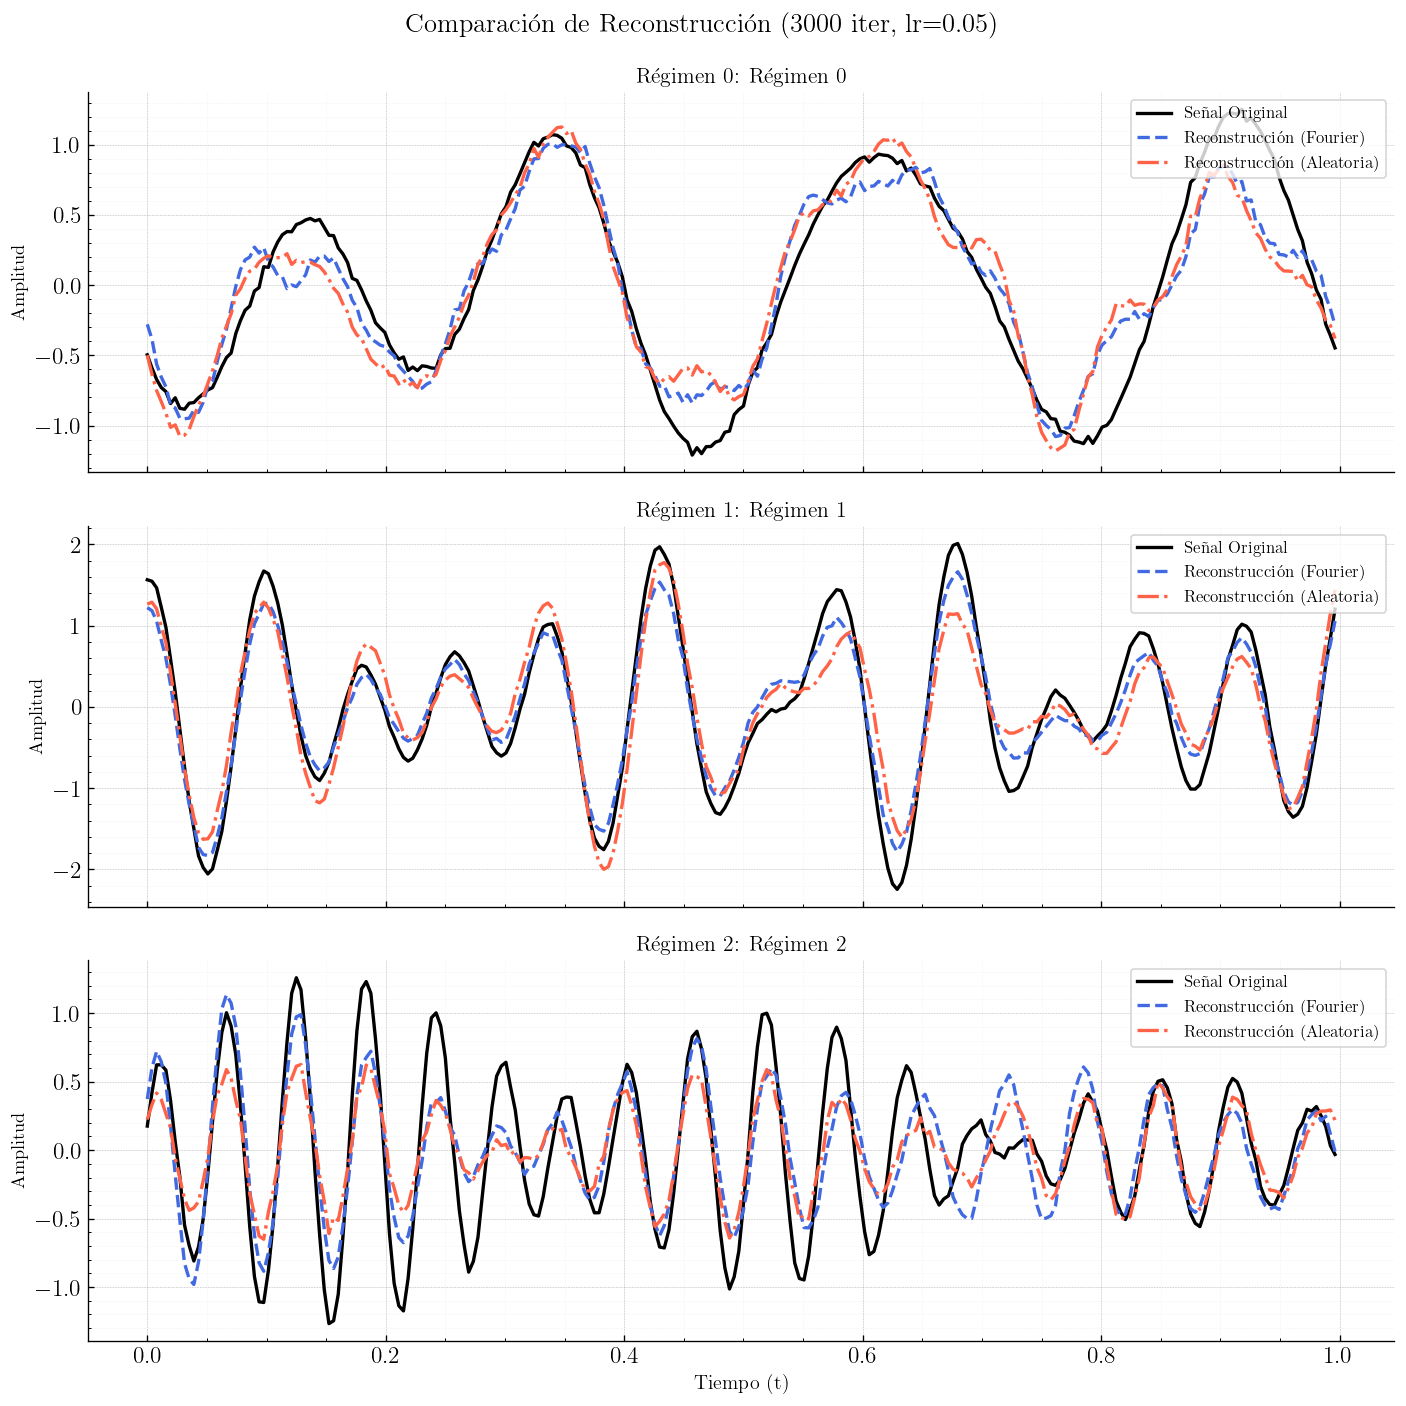

In [6]:
# Comparación de señales

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Lista de cadenas de texto con los nombres descriptivos para cada uno de los 3 regímenes.
nombres_reg = ['Régimen 0', 'Régimen 1', 'Régimen 2']

for reg in regimenes:

    # 1. Filtramos la matriz de datos 'X' usando una máscara booleana (y == reg)
    # para aislar y obtener únicamente las señales que pertenecen al régimen actual.
    X_reg = X[y == reg]

    # 2. Seleccionamos la primera señal (índice 0) de los datos filtrados para usarla como nuestra muestra representativa.
    senal_original = X_reg[0]

    # 3. Pasamos la señal original por el modelo usando los pesos óptimos del entrenamiento aleatorio
    # para generar la predicción/reconstrucción de esa red.
    pred_rand = model(W1_rand_opt, W2_rand_opt, senal_original)

    # 4. Hacemos lo mismo, pero usando los pesos óptimos del entrenamiento inicializado con base de Fourier.
    pred_four = model(W1_four_opt, W2_four_opt, senal_original)

    # Selecciona el subgráfico específico (0, 1 o 2) de la lista 'axes' donde se dibujarán las líneas de esta iteración.
    ax = axes[reg]

    # Traza la señal original en el eje X (tiempo 't') y eje Y (amplitud), usando color negro y un trazo continuo grueso.
    ax.plot(t, senal_original, label='Señal Original', color='black', linewidth=2)

    # Traza la predicción del modelo de Fourier en color azul ('royalblue') y con estilo de línea punteada ('--').
    ax.plot(t, pred_four, label='Reconstrucción (Fourier)', color='royalblue', linestyle='--', linewidth=2)

    # Traza la predicción del modelo aleatorio en color rojo ('tomato') con estilo de línea de punto y raya ('-.').
    ax.plot(t, pred_rand, label='Reconstrucción (Aleatoria)', color='tomato', linestyle='-.', linewidth=2)

    # Configura el título de este subgráfico en particular, inyectando el número y nombre del régimen actual.
    ax.set_title(f'Régimen {reg}: {nombres_reg[reg]}', fontsize=13)

    # Añade la etiqueta 'Amplitud' al eje Y para indicar la unidad de medida vertical.
    ax.set_ylabel('Amplitud', fontsize=11)

  #Malla marcada
    ax.grid(True, which="major", linestyle='--', alpha=0.6, color='gray')
  #Malla tenue
    ax.grid(True, which="minor", linestyle=':', alpha=0.2, color='gray')
    ax.minorticks_on()

    # Agrega la caja de leyenda en la esquina superior derecha del subgráfico para identificar el color y estilo de cada línea.
    ax.legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Tiempo (t)', fontsize=12)

plt.suptitle('Comparación de Reconstrucción (3000 iter, lr=0.05)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# COMPARACIÓN: CURVA DE PÉRDIDA VS CANTIDAD DE ITERACIONES

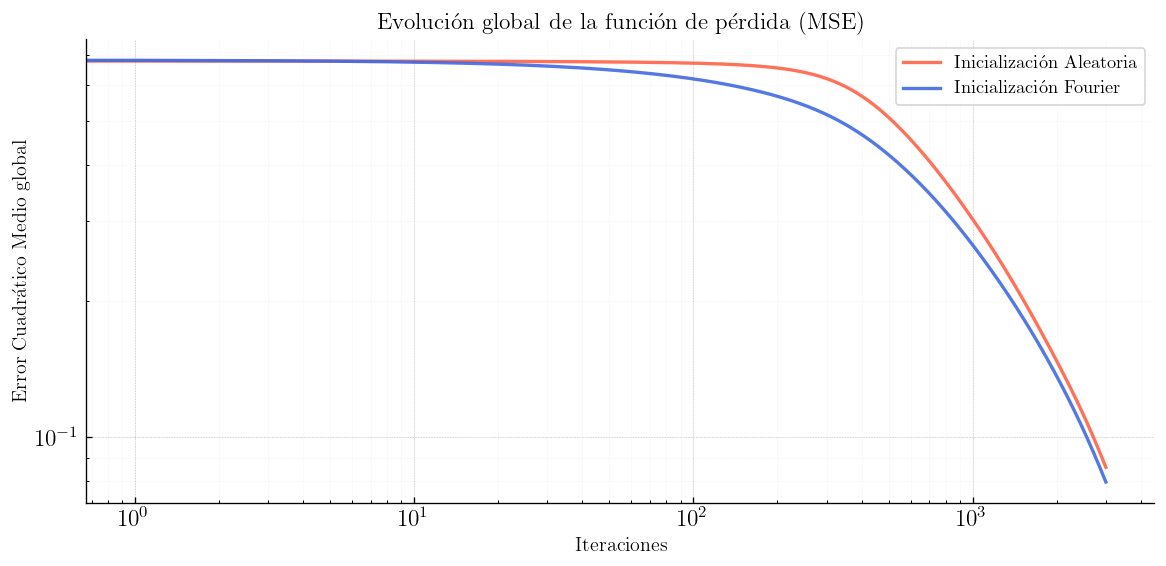

In [7]:
# === GRÁFICA: EVOLUCIÓN GLOBAL DE LA PÉRDIDA ===

# Creamos una figura con un tamaño específico (10 pulgadas de ancho por 5 de alto) para asegurar una visualización clara
plt.figure(figsize=(10, 5))

# Trazamos la línea de pérdida de la inicialización aleatoria en escala logarítmica (loglog) usando el color rojo tomate
plt.loglog(losses_rand, label='Inicialización Aleatoria', color='tomato', alpha=0.9, linewidth=2)

# Trazamos la línea de pérdida de la inicialización de Fourier superpuesta usando el color azul real
plt.loglog(losses_four, label='Inicialización Fourier', color='royalblue', alpha=0.9, linewidth=2)

# Colocamos un título descriptivo en la gráfica que indique claramente qué representa
plt.title('Evolución global de la función de pérdida (MSE)', fontsize=14)

# Etiquetamos el eje horizontal para indicar que mide el transcurso del entrenamiento en iteraciones
plt.xlabel('Iteraciones', fontsize=12)

# Etiquetamos el eje vertical para indicar que representa el Error Cuadrático Medio de todo el dataset
plt.ylabel('Error Cuadrático Medio global', fontsize=12)

# Habilitamos la caja de leyendas para que el lector pueda identificar qué color corresponde a cada inicialización
plt.legend(fontsize=11)

# Malla Marcada
plt.grid(True, which="major", linestyle='--', alpha=0.6, color='gray')
# Malla tenue
plt.grid(True, which="minor", linestyle=':', alpha=0.2, color='gray')
plt.tight_layout()
plt.show()

# CÁLCULO DE LAS ITERACIONES NECESARIOS PARA QUE EL ERROR RELATIVO SEA DE 0.1

In [8]:


def iteracion_exacta_umbral(W1, W2, X_train, lr=0.05, threshold=0.1):
    # Calcula magnitud total de la matriz de entrenamiento para usarla como denominador.
    norma_X = jnp.linalg.norm(X_train)

    # Obtiene la cantidad total de elementos (números individuales) dentro de la matriz X_train.
    size_X = X_train.size

    # Inicializa el contador de épocas/iteraciones en cero.
    iteracion = 0

    # Establece un valor inicial del 100% de error para asegurar que el bucle condicional 'while' se ejecute al menos una vez.
    err_relativo = 1.0

    # Bucle condicional que se repetirá indefinidamente mientras el error relativo calculado sea mayor que el umbral (threshold).
    while err_relativo > threshold:
        # Llama a la función optimizada 'update' para realizar un paso de descenso de gradiente y obtener la pérdida MSE.
        W1, W2, loss = update(W1, W2, X_train, lr)

        # Convierte el MSE (loss) de vuelta a la magnitud del residuo (Raíz de la suma de cuadrados) y lo divide
        # por la norma de la señal original para transformarlo en una métrica de Error Relativo.
        err_relativo = jnp.sqrt(loss * size_X) / norma_X

        # Incrementa en 1 el contador tras completar el paso de entrenamiento.
        iteracion += 1

        # Condicional para imprimir un reporte de estado en la consola cada 2000 iteraciones completadas.
        if iteracion % 2000 == 0:
            # Imprime en pantalla la iteración actual y el valor del error relativo formateado a 4 decimales.
            print(f"Procesando... Iteración {iteracion} | Error actual: {err_relativo:.4f}")

    # Cuando el error cae por debajo del umbral, el ciclo termina y la función devuelve el total de iteraciones y el error final.
    return iteracion, err_relativo

# --- EJECUCIÓN ---

# 1. Prueba con la red de Fourier (Suele converger mucho más rápido)

# Muestra un mensaje informativo en la consola indicando que se inicia el análisis del modelo de Fourier.
print("Buscando la cantidad exacta de iteraciones para la base de FOURIER...")

# Inicializa los pesos combinando las ondas de Fourier en la primera capa y pesos aleatorios en la segunda.
W1_four_init, W2_four_init = init_fourier_params(key, t)

# Ejecuta el bucle de entrenamiento condicional para el modelo de Fourier buscando alcanzar un error menor al 10% (threshold=0.1).
iter_four, err_four = iteracion_exacta_umbral(W1_four_init, W2_four_init, X, lr=0.05, threshold=0.1)

# Imprime el resultado final con el número exacto de iteraciones que le tomó a la red de Fourier converger.
print(f"¡Listo! La inicialización de FOURIER requiere exactamente: {iter_four} iteraciones (Error: {err_four:.4f})\n")

# 2. Prueba con la red Aleatoria

# Muestra un mensaje informativo en la consola indicando que comienza el análisis para el modelo aleatorio estándar.
print("Buscando la cantidad exacta de iteraciones para la base ALEATORIA...")

# Inicializa completamente al azar y con valores pequeños ambas matrices de pesos (W1 y W2).
W1_rand_init, W2_rand_init = init_random_params(key)

# Ejecuta el bucle de entrenamiento condicional para el modelo aleatorio usando los mismos parámetros de control.
iter_rand, err_rand = iteracion_exacta_umbral(W1_rand_init, W2_rand_init, X, lr=0.05, threshold=0.1)
print(f"¡Listo! La inicialización ALEATORIA requiere exactamente: {iter_rand} iteraciones (Error: {err_rand:.4f})")

Buscando la cantidad exacta de iteraciones para la base de FOURIER...


Procesando... Iteración 2000 | Error actual: 0.4489
Procesando... Iteración 4000 | Error actual: 0.2705


Procesando... Iteración 6000 | Error actual: 0.1821
Procesando... Iteración 8000 | Error actual: 0.1287


¡Listo! La inicialización de FOURIER requiere exactamente: 9562 iteraciones (Error: 0.1000)

Buscando la cantidad exacta de iteraciones para la base ALEATORIA...
Procesando... Iteración 2000 | Error actual: 0.4666


Procesando... Iteración 4000 | Error actual: 0.2794
Procesando... Iteración 6000 | Error actual: 0.1912


Procesando... Iteración 8000 | Error actual: 0.1412
Procesando... Iteración 10000 | Error actual: 0.1050


¡Listo! La inicialización ALEATORIA requiere exactamente: 10332 iteraciones (Error: 0.1000)


# VELOCIDAD DE CONVERGENCIA PARA RÉGIMEN 2

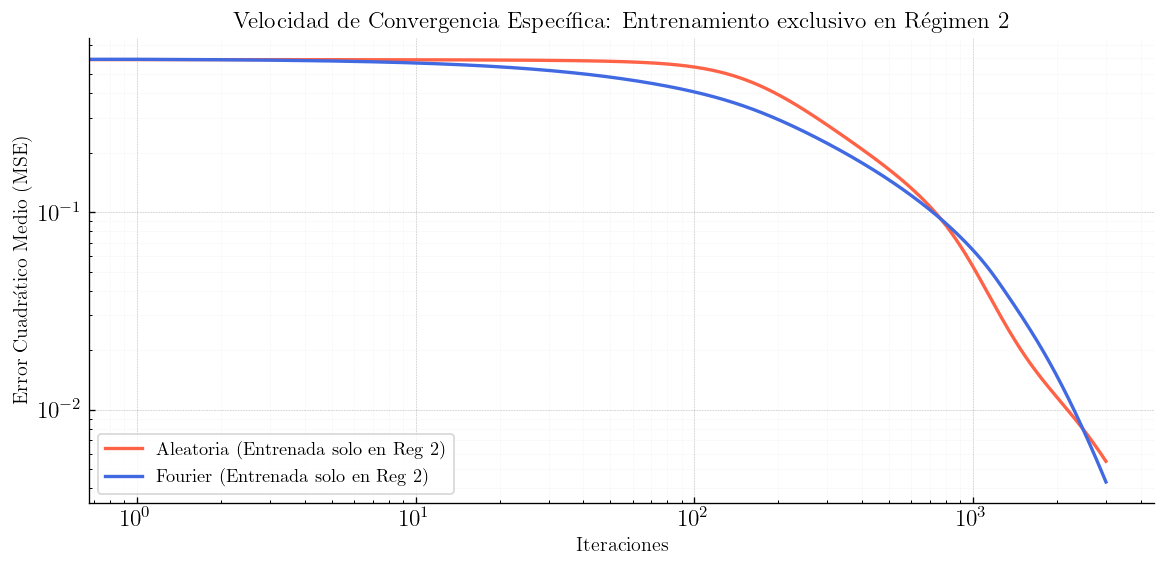

In [9]:
# Filtramos los datos para quedarnos SOLO con las señales del Régimen 2 (etiqueta 2).
X_reg2 = X[y == 2]

# Reiniciamos los pesos de la red aleatoria desde cero para hacer un entrenamiento limpio.
W1_rand_init, W2_rand_init = init_random_params(key)

# Reiniciamos los pesos de la red de Fourier desde cero usando el vector de tiempo t.
W1_four_init, W2_four_init = init_fourier_params(key, t)

# Entrenamos la red usando tu función original, pero le pasamos ÚNICAMENTE los datos del Régimen 2
_, _, losses_rand_solo_reg2 = train_network(W1_rand_init, W2_rand_init, X_reg2, iterations=3000, lr=0.05)

# Repetimos el entrenamiento aislado para la inicialización de Fourier, también solo con el Régimen 2.
_, _, losses_four_solo_reg2 = train_network(W1_four_init, W2_four_init, X_reg2, iterations=3000, lr=0.05)
plt.figure(figsize=(10, 5))

plt.loglog(losses_rand_solo_reg2, label='Aleatoria (Entrenada solo en Reg 2)', color='tomato', linewidth=2)

plt.loglog(losses_four_solo_reg2, label='Fourier (Entrenada solo en Reg 2)', color='royalblue', linewidth=2)
plt.title('Velocidad de Convergencia Específica: Entrenamiento exclusivo en Régimen 2', fontsize=14)
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)

plt.legend(fontsize=11)

# Malla fina
plt.grid(True, which="major", linestyle='--', alpha=0.6, color='gray')
# Malla tenue
plt.grid(True, which="minor", linestyle=':', alpha=0.2, color='gray')
plt.tight_layout()
plt.show()

# COMPRESIÓN: ERROR DE RECONSTRUCCIÓN VS NÚMERO DE COEFICIENTES CONSERVADOS

La mínima cantidad de coeficientes para mantener el 90% de la energía es: 3


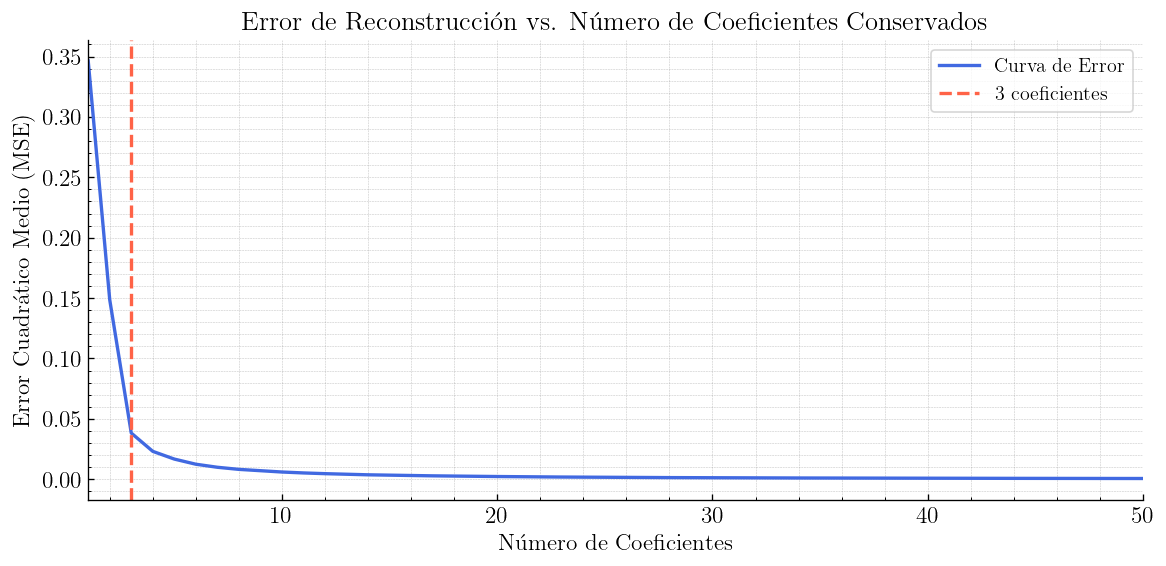

In [10]:


num_signals, N = X.shape # Extraemos la cantidad de señales y la longitud (256) directamente de X

# La FFT para señales reales (rfft) produce N//2 + 1 coeficientes
num_coefs_max = N // 2 + 1

# Arreglos para almacenar los promedios globales
errores_por_c = np.zeros(num_coefs_max)
energia_por_c = np.zeros(num_coefs_max)

# 2. Iterar sobre todas las señales para sacar un comportamiento promedio
for i in range(num_signals):
    x = X[i]

    # Transformada de Fourier
    X_fft = np.fft.rfft(x)

    # Energía total de la señal original
    energia_total = np.sum(x**2)

    # Ordenar los índices de los coeficientes de mayor a menor magnitud
    indices_ordenados = np.argsort(np.abs(X_fft))[::-1]

    error_senal = []
    energia_senal = []

    # Evaluar la reconstrucción agregando coeficientes uno por uno
    for c in range(1, num_coefs_max + 1):
        # Crear un espectro vacío y llenarlo solo con los 'c' coeficientes principales
        X_fft_trunc = np.zeros_like(X_fft)
        X_fft_trunc[indices_ordenados[:c]] = X_fft[indices_ordenados[:c]]

        # Transformada inversa para reconstruir la señal
        x_rec = np.fft.irfft(X_fft_trunc, n=N)

        # Error Cuadrático Medio de reconstrucción
        error = np.mean((x - x_rec)**2)
        error_senal.append(error)

        # Energía retenida vs Energía original
        energia_ret = np.sum(x_rec**2)
        energia_senal.append(energia_ret / energia_total)

    errores_por_c += np.array(error_senal)
    energia_por_c += np.array(energia_senal)

# Promediar los resultados dividiendo entre el total de señales
errores_por_c /= num_signals
energia_por_c /= num_signals

# 3. Encontrar la cantidad mínima de coeficientes para el 90% de energía
# np.argmax devuelve el primer índice que cumple la condición
min_coefs = np.argmax(energia_por_c >= 0.90) + 1

print(f"La mínima cantidad de coeficientes para mantener el 90% de la energía es: {min_coefs}")

# 4. Generar la gráfica solicitada
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_coefs_max + 1), errores_por_c, color='royalblue', linewidth=2, label='Curva de Error')

# Añadir una línea vertical en el punto de corte del 85%
plt.axvline(x=min_coefs, color='tomato', linestyle='--', linewidth=2,
            label=f'{min_coefs} coeficientes')

# Estética científica
plt.title('Error de Reconstrucción vs. Número de Coeficientes Conservados', fontsize=16)
plt.xlabel('Número de Coeficientes', fontsize=14)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xlim(1, 50) # Hacemos zoom en los primeros 50 para que se vea claro, puedes ajustarlo
plt.tight_layout()
plt.show()